# Model-based clustering and how to evaluate it

Why fitting a mixture is clustering, the difference between hard (argmax) and soft (probabilistic) assignment and when the soft version matters, and how to evaluate clusters two ways: against known labels (adjusted Rand index, normalized mutual information) and without any labels (silhouette). The model-based view gives you something k-means can't: a probability and an uncertainty for every assignment.


## What a clustering is, and how to score it

A clustering partitions $n$ points into groups. Model-based clustering obtains it from a fitted mixture:
the hard assignment is $\hat z_i=\arg\max_k r_{ik}$, and the responsibilities $r_{ik}$ themselves report
assignment confidence. Evaluating a clustering splits into two cases: external metrics compare to known
labels, internal metrics use only geometry.

Definition (Rand index). Over all $\binom{n}{2}$ pairs of points, the Rand index is the fraction on
which two partitions agree (both put the pair together, or both apart). It lies in $[0,1]$ but does not
account for agreement expected by chance.

Definition (adjusted Rand index, ARI). The chance-corrected version,
$$\mathrm{ARI} = \frac{\mathrm{RI} - \mathbb E[\mathrm{RI}]}{\max(\mathrm{RI}) - \mathbb E[\mathrm{RI}]},$$
where $\mathbb E[\mathrm{RI}]$ is computed under the hypergeometric model of random partitions with the
observed group sizes. ARI is $0$ in expectation for independent labelings and $1$ for perfect agreement.

Definition (normalized mutual information, NMI). With $I(U;V)$ the mutual information between the two
label assignments and $H$ the entropy, $\mathrm{NMI}=I(U;V)/\sqrt{H(U)H(V)}\in[0,1]$. It captures shared
information rather than pairwise agreement.

## Why chance correction matters

Theorem (the unadjusted Rand index inflates with the number of clusters). If a partition into $K$ groups
is drawn at random, the expected Rand index against any fixed reference tends to $1$ as $K$ grows,
because most pairs are placed apart and "both apart" counts as agreement. A method that simply reports
more clusters can therefore post a high Rand index while carrying no real information. ARI subtracts
exactly this expected agreement, so a random labeling scores about $0$ regardless of $K$.

Sketch. With $K$ growing, the probability two random points share a cluster is about $1/K\to 0$, so
nearly every pair is "apart" in both partitions and the raw agreement rate $\to 1$. The ARI numerator
removes the chance term $\mathbb E[\mathrm{RI}]$, which carries this same inflation, leaving a value near
zero. We confirm both behaviors below.

Definition (silhouette). For point $i$ let $a_i$ be its mean distance to its own cluster and $b_i$ its
mean distance to the nearest other cluster; the silhouette is $s_i=(b_i-a_i)/\max(a_i,b_i)\in[-1,1]$.
The average silhouette needs no labels and is often used to choose $K$, peaking when clusters are
compact and well separated.

Counterexample (metrics disagree). Internal and external metrics optimize different things. Silhouette
rewards spherical, separated clusters and can prefer the wrong $K$ for elongated or unequal clusters,
where BIC on a flexible-covariance mixture does better. No single number is sufficient; report several and
understand what each measures.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
from mixle.stats import DiagonalGaussianEstimator, DiagonalGaussianDistribution, MixtureEstimator, MixtureDistribution
from mixle.inference.estimation import optimize
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
rng = np.random.RandomState(0)

# three roughly-spherical clusters with thin boundary overlap (so soft assignment is visible)
centers = np.array([[0, 0], [4, 4], [8, 0]])
X = np.vstack([rng.normal(c, 0.9, (250, 2)) for c in centers])
true_labels = np.repeat([0, 1, 2], 250)
data = [list(map(float, r)) for r in X]

def fit_seeded(data, K, max_its=60, seed=0):
    arr = np.asarray(data); cen = KMeans(K, n_init=5, random_state=seed).fit(arr).cluster_centers_
    sd = arr.std(axis=0)
    sm = MixtureDistribution([DiagonalGaussianDistribution(list(map(float, c)), list(map(float, sd ** 2))) for c in cen], [1.0 / K] * K)
    return optimize(data, MixtureEstimator([DiagonalGaussianEstimator(dim=arr.shape[1])] * K), max_its=max_its, prev_estimate=sm, print_iter=100)

## 1. Clustering = fitting a mixture

A clustering model is just a mixture: each component is a cluster, and the fitted responsibilities $r_{ik}=P(\text{component }k\mid x_i)$ are soft cluster memberships. Take the argmax for a hard label, or keep the whole vector for a soft, uncertainty-aware assignment. We fit $K=3$ and read both.


Iteration 10: ln[p_mat(Data|Model)]=-2.758344e+03, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=5.811671e-10


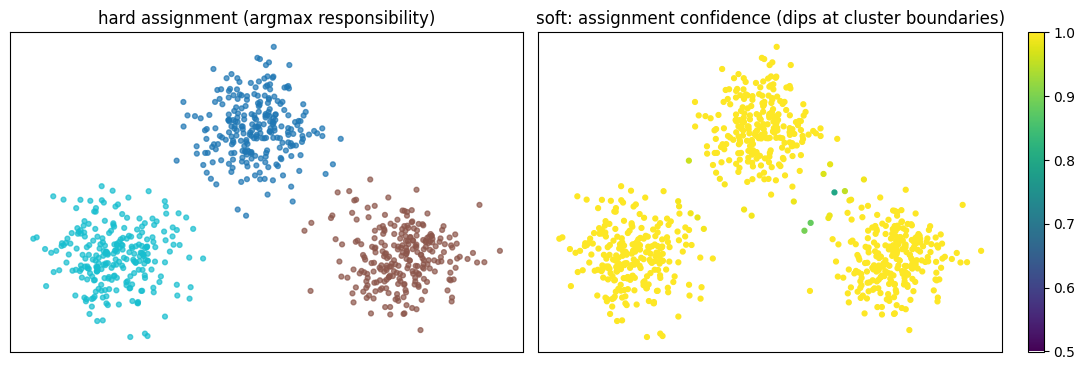

In [2]:
model = fit_seeded(data, 3)
resp = np.asarray(model.seq_posterior(model.dist_to_encoder().seq_encode(data)))   # (N, K) soft
hard = resp.argmax(1)                                                              # hard labels
confidence = resp.max(1)                                                           # how sure?

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].scatter(X[:, 0], X[:, 1], c=hard, cmap='tab10', s=12, alpha=0.7)
ax[0].set_title('hard assignment (argmax responsibility)'); ax[0].set_xticks([]); ax[0].set_yticks([])
sc = ax[1].scatter(X[:, 0], X[:, 1], c=confidence, cmap='viridis', s=12, vmin=0.5, vmax=1.0)
ax[1].set_title('soft: assignment confidence (dips at cluster boundaries)'); ax[1].set_xticks([]); ax[1].set_yticks([])
fig.colorbar(sc, ax=ax[1], fraction=0.046)
plt.tight_layout(); plt.show()

## 2. External evaluation: comparing to known labels

When you have ground-truth labels (a benchmark, or for validation), score the clustering against them. Both standard metrics are permutation-invariant (they don't care that "cluster 0" might be "class 2") and chance-corrected:

- Adjusted Rand index (ARI): agreement of point pairs, 0 = chance, 1 = perfect.
- Normalized mutual information (NMI): shared information between the two labelings, in $[0,1]$.

We compare the model's hard labels to the truth, and to k-means as a baseline. On clean, roughly spherical clusters k-means is already near-optimal, so expect the two to tie here - the mixture's distinct value (calibrated uncertainty in §1, and non-spherical shapes in the exercises) lies elsewhere.


In [3]:
km = KMeans(3, n_init=5, random_state=0).fit(X).labels_
print('model-based GMM : ARI=%.3f  NMI=%.3f' % (adjusted_rand_score(true_labels, hard),
                                                normalized_mutual_info_score(true_labels, hard)))
print('k-means baseline: ARI=%.3f  NMI=%.3f' % (adjusted_rand_score(true_labels, km),
                                                normalized_mutual_info_score(true_labels, km)))

model-based GMM : ARI=0.996  NMI=0.992
k-means baseline: ARI=0.996  NMI=0.992


## 3. Internal evaluation: no labels needed

Usually you have no labels - that's why you're clustering. Internal metrics judge a clustering by its geometry alone. The silhouette score compares each point's distance to its own cluster vs the nearest other cluster ($+1$ tight and well-separated, $0$ on a boundary, $<0$ likely misassigned). Sweeping $K$ and reading silhouette is a label-free way to choose the number of clusters.


Iteration 17: ln[p_mat(Data|Model)]=-3.286982e+03, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=6.757546e-10
Iteration 10: ln[p_mat(Data|Model)]=-2.758344e+03, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=5.811671e-10


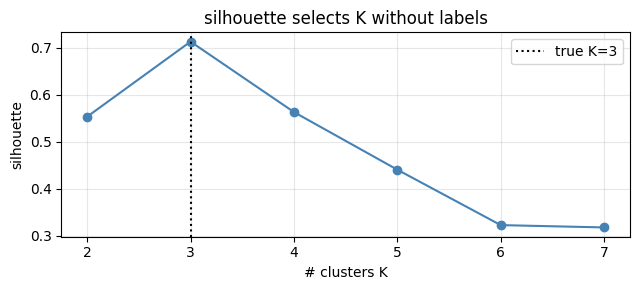

silhouette selects K=3


In [4]:
Ks = list(range(2, 8))
sil = []
for K in Ks:
    mk = fit_seeded(data, K)
    h = np.asarray(mk.seq_posterior(mk.dist_to_encoder().seq_encode(data))).argmax(1)
    sil.append(silhouette_score(X, h))
fig, ax = plt.subplots(figsize=(6.5, 3))
ax.plot(Ks, sil, 'o-', color='steelblue'); ax.axvline(3, color='k', ls=':', label='true K=3')
ax.set_xlabel('# clusters K'); ax.set_ylabel('silhouette'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('silhouette selects K without labels')
plt.tight_layout(); plt.show()
print('silhouette selects K=%d' % Ks[int(np.argmax(sil))])

## 4. Why model-based clustering

k-means draws hard spherical boundaries; a Gaussian mixture learns each cluster's shape and spread and returns a probability per assignment - so it handles overlapping and elongated clusters and, crucially, tells you when it isn't sure (the low-confidence band in §1). That probabilistic output is what lets clusters plug into the rest of a probabilistic model (mixtures of composites, semi-supervised learning, anomaly scores) rather than being a dead-end label.


## Cluster stability to choose K without labels

When you have no ground truth, a principled label-free criterion is stability (von Luxburg): a good $K$ gives clusterings that agree across resamples of the data. We bootstrap the data, refit at each $K$, and measure the average adjusted-Rand agreement of the bootstrap clusterings with the full-data clustering - the most stable $K$ is the trustworthy one.


In [5]:
from sklearn.metrics import adjusted_rand_score
def assign_at(model, pts):
    return np.asarray(model.seq_posterior(model.dist_to_encoder().seq_encode(pts))).argmax(1)
base = {K: assign_at(fit_seeded(data, K), data) for K in range(2, 7)}
stab = {}
for K in range(2, 7):
    agrees = []
    for b in range(8):
        idx = np.random.RandomState(b).randint(0, len(data), len(data))
        bm = fit_seeded([data[i] for i in idx], K, seed=b)
        agrees.append(adjusted_rand_score(base[K][idx], assign_at(bm, [data[i] for i in idx])))
    stab[K] = float(np.mean(agrees))
print('stability (mean bootstrap ARI) by K:', {k: round(v, 3) for k, v in stab.items()})
print('most stable K = %d  (truth 3)' % max(stab, key=stab.get))

Iteration 17: ln[p_mat(Data|Model)]=-3.286982e+03, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=6.757546e-10
Iteration 10: ln[p_mat(Data|Model)]=-2.758344e+03, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=5.811671e-10


Iteration 19: ln[p_mat(Data|Model)]=-3.282715e+03, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=4.665708e-10
Iteration 18: ln[p_mat(Data|Model)]=-3.283525e+03, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=7.794370e-10


Iteration 18: ln[p_mat(Data|Model)]=-3.259103e+03, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=4.843059e-10
Iteration 15: ln[p_mat(Data|Model)]=-3.253822e+03, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=4.974936e-10
Iteration 17: ln[p_mat(Data|Model)]=-3.271850e+03, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=2.796696e-10


Iteration 22: ln[p_mat(Data|Model)]=-3.268494e+03, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=4.711183e-10
Iteration 18: ln[p_mat(Data|Model)]=-3.291350e+03, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=4.320100e-10


Iteration 18: ln[p_mat(Data|Model)]=-3.299561e+03, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=4.288268e-10
Iteration 10: ln[p_mat(Data|Model)]=-2.778937e+03, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=5.306902e-10


Iteration 11: ln[p_mat(Data|Model)]=-2.785282e+03, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=8.185452e-10
Iteration 9: ln[p_mat(Data|Model)]=-2.725464e+03, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=2.132765e-10


Iteration 11: ln[p_mat(Data|Model)]=-2.685671e+03, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=1.164153e-10
Iteration 11: ln[p_mat(Data|Model)]=-2.727541e+03, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=2.937668e-10


Iteration 10: ln[p_mat(Data|Model)]=-2.729289e+03, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=6.548362e-11
Iteration 10: ln[p_mat(Data|Model)]=-2.764057e+03, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=4.743015e-10
Iteration 9: ln[p_mat(Data|Model)]=-2.756650e+03, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=7.698873e-10


stability (mean bootstrap ARI) by K: {2: 0.763, 3: 1.0, 4: 0.905, 5: 0.732, 6: 0.66}
most stable K = 3  (truth 3)


## Illustration: raw Rand inflates, adjusted Rand does not

We compare a fixed ground-truth labeling against purely random labelings with a growing number of
clusters. The raw Rand index climbs toward one as the cluster count grows, falsely suggesting agreement,
while the adjusted Rand index stays near zero, which is the correct verdict for random labels.

In [6]:
from sklearn.metrics import rand_score, adjusted_rand_score
rng = np.random.RandomState(0)
n = 600; truth = rng.randint(0, 4, n)
print(' clusters K     raw Rand     adjusted Rand (chance-corrected)')
for K in [2, 5, 20, 100]:
    raws, adjs = [], []
    for _ in range(50):
        rand_labels = rng.randint(0, K, n)
        raws.append(rand_score(truth, rand_labels)); adjs.append(adjusted_rand_score(truth, rand_labels))
    print('   %4d         %.3f          %+.3f' % (K, np.mean(raws), np.mean(adjs)))
print('raw Rand -> 1 with more clusters (spurious); ARI stays ~0, correctly reporting no agreement.')

 clusters K     raw Rand     adjusted Rand (chance-corrected)
      2         0.500          +0.000
      5         0.650          -0.001


     20         0.725          -0.000
    100         0.745          +0.000
raw Rand -> 1 with more clusters (spurious); ARI stays ~0, correctly reporting no agreement.


## References

- Hubert, L. & Arabie, P. (1985). Comparing partitions (https://doi.org/10.1007/BF01908075). J. Classification 2, 193-218. - the adjusted Rand index.
- Rousseeuw, P. J. (1987). Silhouettes: a graphical aid to the interpretation and validation of cluster analysis (https://doi.org/10.1016/0377-0427(87)90125-7). J. Comp. Appl. Math. 20, 53-65.
- Vinh, N. X., Epps, J. & Bailey, J. (2010). Information theoretic measures for clusterings comparison (https://jmlr.org/papers/v11/vinh10a.html). JMLR 11, 2837-2854. - adjusted mutual information.
- Tibshirani, R., Walther, G. & Hastie, T. (2001). Estimating the number of clusters via the gap statistic (https://doi.org/10.1111/1467-9868.00293). JRSS-B 63(2), 411-423.
- von Luxburg, U. (2010). Clustering stability: an overview (https://doi.org/10.1561/2200000008). Found. Trends ML 2(3).


## Exercises and extensions

1. External-metric panel and chance correction. Implement Rand, adjusted Rand (Hubert-Arabie), normalized and adjusted mutual information (Vinh et al.), V-measure, and Fowlkes-Mallows. Show empirically why chance correction matters: as the number of clusters grows, uncorrected metrics drift upward even for random labelings.
2. Internal-metric panel and choosing K without labels. Compare silhouette, Calinski-Harabasz, Davies-Bouldin, and the gap statistic (Tibshirani et al.) for selecting $K$. Construct a dataset where they disagree and relate each metric's bias (e.g. toward equal-size or spherical clusters).
3. Cluster stability. Implement bootstrap/subsampling stability (von Luxburg): refit on resamples and measure how consistently point pairs co-cluster. Use stability to choose $K$ and compare to BIC and silhouette; discuss when stability is the more honest criterion.
4. Is the soft assignment calibrated?. Bin points by their max responsibility and check whether the empirical correctness matches the responsibility (a reliability diagram for clustering); relate to classification_metrics_and_calibration.
